# 📊 YOLO 답안 인식 정확도 분석 (유형별 분석 포함)

## 개요
- **results_summary.txt**: 파일명, 페이지번호, 문제번호, 예측답안
  - 예: `학생이 푼 문제(실전 모의고사) - 1, 88, 04, 3`
- **test_answer.txt**: 페이지번호, 문제번호, 정답, 유형 (정답지)
  - 예: `9, 01, 4, answer_12_xo`

정답지를 기준으로 **페이지번호 + 문제번호**로 매칭하여 정확도를 계산하고, **유형별 오답 비율**도 분석합니다.

In [1]:
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 파일 경로 설정

In [2]:
# 파일 경로 설정 (필요시 수정)
results_path = Path("results_summary.txt")
answer_key_path = Path("test_answer.txt")
output_dir = Path("./")

# 파일 존재 확인
if not results_path.exists():
    print(f"❌ 파일을 찾을 수 없습니다: {results_path}")
else:
    print(f"✅ Results 파일: {results_path}")

if not answer_key_path.exists():
    print(f"❌ 파일을 찾을 수 없습니다: {answer_key_path}")
else:
    print(f"✅ Answer Key 파일: {answer_key_path}")

✅ Results 파일: results_summary.txt
✅ Answer Key 파일: test_answer.txt


## 2. 데이터 로드 및 전처리

In [3]:
def load_results(file_path: Path) -> pd.DataFrame:
    """results_summary.txt 로드
    형식: 파일명, 페이지번호, 문제번호, 예측답안
    예: 학생이 푼 문제(실전 모의고사) - 1, 88, 04, 3
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 4:
                data.append({
                    'file_name': parts[0],
                    'page_number': parts[1],
                    'problem_number': parts[2],
                    'predicted_answer': parts[3] if parts[3].lower() != 'none' else None
                })
            else:
                print(f"⚠️ Warning: 라인 {line_num} 형식 오류: {line}")
    
    df = pd.DataFrame(data)
    print(f"\n📄 Results Summary 로드 완료: {len(df)}개 항목")
    print(f"   - None 답안: {df['predicted_answer'].isna().sum()}개")
    print(f"   - 파일명: {df['file_name'].nunique()}개 고유 파일")
    print(f"   - 페이지 수: {df['page_number'].nunique()}개 고유 페이지")
    return df

def load_answer_key(file_path: Path) -> pd.DataFrame:
    """test_answer.txt 로드 (정답지)
    형식: 페이지번호, 문제번호, 정답, 유형
    예: 9, 01, 4, answer_12_xo
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 4:
                data.append({
                    'page_number': parts[0],
                    'problem_number': parts[1],
                    'correct_answer': parts[2],
                    'problem_type': parts[3]
                })
            else:
                print(f"⚠️ Warning: 라인 {line_num} 형식 오류: {line}")
    
    df = pd.DataFrame(data)
    print(f"\n📘 Answer Key 로드 완료: {len(df)}개 항목")
    print(f"   - 유형 정보: {df['problem_type'].notna().sum()}개 문제에 유형 있음")
    if df['problem_type'].notna().sum() > 0:
        print(f"   - 유형 종류: {df['problem_type'].nunique()}가지 ({', '.join(df['problem_type'].dropna().unique())})")
    print(f"   - 페이지 수: {df['page_number'].nunique()}개 고유 페이지")
    return df

# 데이터 로드
results_df = load_results(results_path)
answer_key_df = load_answer_key(answer_key_path)

print("\n" + "="*60)


📄 Results Summary 로드 완료: 292개 항목
   - None 답안: 2개
   - 파일명: 147개 고유 파일
   - 페이지 수: 147개 고유 페이지

📘 Answer Key 로드 완료: 290개 항목
   - 유형 정보: 290개 문제에 유형 있음
   - 유형 종류: 8가지 (answer_12_xo, answer_12_ox, answer_12_xx, answer_1_x, answer_1_o, answer_2_x, answer_2_o, answer_12_oo)
   - 페이지 수: 147개 고유 페이지



## 3. 데이터 샘플 확인

In [4]:
print("\n📋 Results Summary 샘플:")
display(results_df.head(10))

print("\n📋 Answer Key 샘플:")
display(answer_key_df.head(10))


📋 Results Summary 샘플:


,file_name,page_number,problem_number,predicted_answer
0,학생이 푼 문제(실전 모의고사) - 1,88,04,3
1,학생이 푼 문제(실전 모의고사) - 1,88,01,4
2,학생이 푼 문제(실전 모의고사) - 1,88,02,2
3,학생이 푼 문제(실전 모의고사) - 1,88,05,3
4,학생이 푼 문제(실전 모의고사) - 1,88,03,3
5,학생이 푼 문제(실전 모의고사) - 10,97,29,3
6,학생이 푼 문제(실전 모의고사) - 10,97,30,2
7,학생이 푼 문제(실전 모의고사) - 11,98,32,5
8,학생이 푼 문제(실전 모의고사) - 11,98,31,3
9,학생이 푼 문제(실전 모의고사) - 12,99,34,4



📋 Answer Key 샘플:


,page_number,problem_number,correct_answer,problem_type
0,9,01,4,answer_12_xo
1,10,02,4,answer_12_xo
2,11,03,3,answer_12_xo
3,12,04,5,answer_12_xo
4,13,05,4,answer_12_xo
5,15,01,1,answer_12_xo
6,16,02,3,answer_12_xo
7,17,03,5,answer_12_xo
8,18,04,5,answer_12_xo
9,19,05,5,answer_12_xo


## 4. 정답 비교 (페이지번호 + 문제번호 기준)

In [5]:
# 정답지를 기준으로 results와 merge (페이지번호 + 문제번호로 매칭)
merged_df = answer_key_df.merge(
    results_df,
    on=['page_number', 'problem_number'],
    how='left',
    indicator=True
)

# 비교 결과 컬럼 추가
def compare_answers(row):
    """정답 비교"""
    if row['_merge'] == 'left_only':
        return 'missing'  # results에 없음
    elif pd.isna(row['predicted_answer']):
        return 'none'  # None으로 예측됨
    elif str(row['predicted_answer']).strip() == str(row['correct_answer']).strip():
        return 'correct'  # 정답
    else:
        return 'wrong'  # 오답

merged_df['result'] = merged_df.apply(compare_answers, axis=1)

print("\n✅ 정답 비교 완료 (페이지번호 + 문제번호 기준)")
print("\n📊 전체 결과:")
display(merged_df.head(20))


✅ 정답 비교 완료 (페이지번호 + 문제번호 기준)

📊 전체 결과:


,page_number,problem_number,correct_answer,problem_type,file_name,predicted_answer,_merge,result
0,9,01,4,answer_12_xo,학생이 푼 문제(유형편) - 1,4,both,correct
1,10,02,4,answer_12_xo,학생이 푼 문제(유형편) - 2,4,both,correct
2,11,03,3,answer_12_xo,학생이 푼 문제(유형편) - 3,3,both,correct
3,12,04,5,answer_12_xo,학생이 푼 문제(유형편) - 4,5,both,correct
4,13,05,4,answer_12_xo,학생이 푼 문제(유형편) - 5,4,both,correct
5,15,01,1,answer_12_xo,학생이 푼 문제(유형편) - 6,1,both,correct
6,16,02,3,answer_12_xo,학생이 푼 문제(유형편) - 7,3,both,correct
7,17,03,5,answer_12_xo,학생이 푼 문제(유형편) - 8,5,both,correct
8,18,04,5,answer_12_xo,학생이 푼 문제(유형편) - 9,5,both,correct
9,19,05,5,answer_12_xo,학생이 푼 문제(유형편) - 10,5,both,correct


## 5. 정확도 계산

In [6]:
# 결과별 개수 계산
total_count = len(merged_df)
correct_count = (merged_df['result'] == 'correct').sum()
wrong_count = (merged_df['result'] == 'wrong').sum()
none_count = (merged_df['result'] == 'none').sum()
missing_count = (merged_df['result'] == 'missing').sum()

# 정확도 계산
accuracy = correct_count / total_count * 100 if total_count > 0 else 0

# 인식 성공률 (누락 제외)
recognized_count = total_count - missing_count
recognition_rate = recognized_count / total_count * 100 if total_count > 0 else 0

# 인식된 것 중 정확도
accuracy_of_recognized = correct_count / recognized_count * 100 if recognized_count > 0 else 0

print("="*60)
print("📊 정확도 통계")
print("="*60)
print(f"\n📘 정답지 기준:")
print(f"   총 문제 수: {total_count}개")
print(f"\n✅ 정답: {correct_count}개 ({correct_count/total_count*100:.2f}%)")
print(f"❌ 오답: {wrong_count}개 ({wrong_count/total_count*100:.2f}%)")
print(f"⚠️ None: {none_count}개 ({none_count/total_count*100:.2f}%)")
print(f"🔍 누락: {missing_count}개 ({missing_count/total_count*100:.2f}%)")
print(f"\n{'='*60}")
print(f"🎯 전체 정확도: {accuracy:.2f}%")
print(f"📝 인식 성공률 (누락 제외): {recognition_rate:.2f}%")
print(f"✨ 인식된 것 중 정확도 (None 포함): {accuracy_of_recognized:.2f}%")
print("="*60)

📊 정확도 통계

📘 정답지 기준:
   총 문제 수: 290개

✅ 정답: 287개 (98.97%)
❌ 오답: 3개 (1.03%)
⚠️ None: 0개 (0.00%)
🔍 누락: 0개 (0.00%)

🎯 전체 정확도: 98.97%
📝 인식 성공률 (누락 제외): 100.00%
✨ 인식된 것 중 정확도 (None 포함): 98.97%


## 6. 유형별 오답 비율 분석 ⭐ NEW

In [7]:
# 유형별 통계 계산
if merged_df['problem_type'].notna().sum() > 0:
    type_stats = merged_df.groupby('problem_type').agg({
        'result': 'count'
    }).rename(columns={'result': 'total'})
    
    type_stats['correct'] = merged_df[merged_df['result'] == 'correct'].groupby('problem_type').size()
    type_stats['wrong'] = merged_df[merged_df['result'] == 'wrong'].groupby('problem_type').size()
    type_stats['none'] = merged_df[merged_df['result'] == 'none'].groupby('problem_type').size()
    type_stats['missing'] = merged_df[merged_df['result'] == 'missing'].groupby('problem_type').size()
    
    type_stats = type_stats.fillna(0).astype(int)
    
    # 정확도 및 오답률 계산
    type_stats['accuracy'] = (type_stats['correct'] / type_stats['total'] * 100).round(2)
    type_stats['wrong_rate'] = (type_stats['wrong'] / type_stats['total'] * 100).round(2)
    type_stats['none_rate'] = (type_stats['none'] / type_stats['total'] * 100).round(2)
    type_stats['missing_rate'] = (type_stats['missing'] / type_stats['total'] * 100).round(2)
    
    # 오답률 기준으로 정렬
    type_stats = type_stats.sort_values('wrong_rate', ascending=False)
    
    print("="*80)
    print("📊 유형별 정확도 및 오답 비율 분석")
    print("="*80)
    display(type_stats)
    
    # 오답률이 높은 유형 강조
    high_wrong_rate = type_stats[type_stats['wrong_rate'] > 10]
    if len(high_wrong_rate) > 0:
        print("\n⚠️ 오답률이 10% 이상인 유형:")
        display(high_wrong_rate[['total', 'wrong', 'wrong_rate', 'accuracy']])
    
    # 유형별 상세 분석
    print("\n" + "="*80)
    print("📈 유형별 상세 분석")
    print("="*80)
    for problem_type in type_stats.index:
        stats = type_stats.loc[problem_type]
        print(f"\n🔹 유형: {problem_type}")
        print(f"   총 문제: {stats['total']}개")
        print(f"   ✅ 정답: {stats['correct']}개 ({stats['accuracy']:.2f}%)")
        print(f"   ❌ 오답: {stats['wrong']}개 ({stats['wrong_rate']:.2f}%)")
        print(f"   ⚠️ None: {stats['none']}개 ({stats['none_rate']:.2f}%)")
        print(f"   🔍 누락: {stats['missing']}개 ({stats['missing_rate']:.2f}%)")
        
        # 해당 유형의 오답 샘플 출력
        type_wrong = merged_df[(merged_df['problem_type'] == problem_type) & (merged_df['result'] == 'wrong')]
        if len(type_wrong) > 0:
            print(f"   📋 오답 샘플 (최대 3개):")
            for idx, row in type_wrong.head(3).iterrows():
                print(f"      - 페이지 {row['page_number']}, 문제 {row['problem_number']}: 정답={row['correct_answer']}, 예측={row['predicted_answer']}")
else:
    print("⚠️ 유형 정보가 없어 유형별 분석을 수행할 수 없습니다.")

📊 유형별 정확도 및 오답 비율 분석


,total,correct,wrong,none,missing,accuracy,wrong_rate,none_rate,missing_rate
problem_type,,,,,,,,,
answer_1_o,45,42,3,0,0,93.33,6.67,0.0,0.0
answer_12_oo,29,29,0,0,0,100.00,0.00,0.0,0.0
answer_12_xo,27,27,0,0,0,100.00,0.00,0.0,0.0
answer_12_ox,27,27,0,0,0,100.00,0.00,0.0,0.0
answer_12_xx,27,27,0,0,0,100.00,0.00,0.0,0.0
answer_1_x,45,45,0,0,0,100.00,0.00,0.0,0.0
answer_2_o,45,45,0,0,0,100.00,0.00,0.0,0.0
answer_2_x,45,45,0,0,0,100.00,0.00,0.0,0.0



📈 유형별 상세 분석

🔹 유형: answer_1_o
   총 문제: 45.0개
   ✅ 정답: 42.0개 (93.33%)
   ❌ 오답: 3.0개 (6.67%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)
   📋 오답 샘플 (최대 3개):
      - 페이지 105, 문제 04: 정답=4, 예측=5
      - 페이지 106, 문제 10: 정답=4, 예측=1
      - 페이지 112, 문제 25: 정답=4, 예측=2

🔹 유형: answer_12_oo
   총 문제: 29.0개
   ✅ 정답: 29.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)

🔹 유형: answer_12_xo
   총 문제: 27.0개
   ✅ 정답: 27.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)

🔹 유형: answer_12_ox
   총 문제: 27.0개
   ✅ 정답: 27.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)

🔹 유형: answer_12_xx
   총 문제: 27.0개
   ✅ 정답: 27.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)

🔹 유형: answer_1_x
   총 문제: 45.0개
   ✅ 정답: 45.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0.0개 (0.00%)
   🔍 누락: 0.0개 (0.00%)

🔹 유형: answer_2_o
   총 문제: 45.0개
   ✅ 정답: 45.0개 (100.00%)
   ❌ 오답: 0.0개 (0.00%)
   ⚠️ None: 0

## 7. 유형별 시각화 ⭐ NEW


💾 유형별 분석 시각화 저장: type_analysis_visualization.png


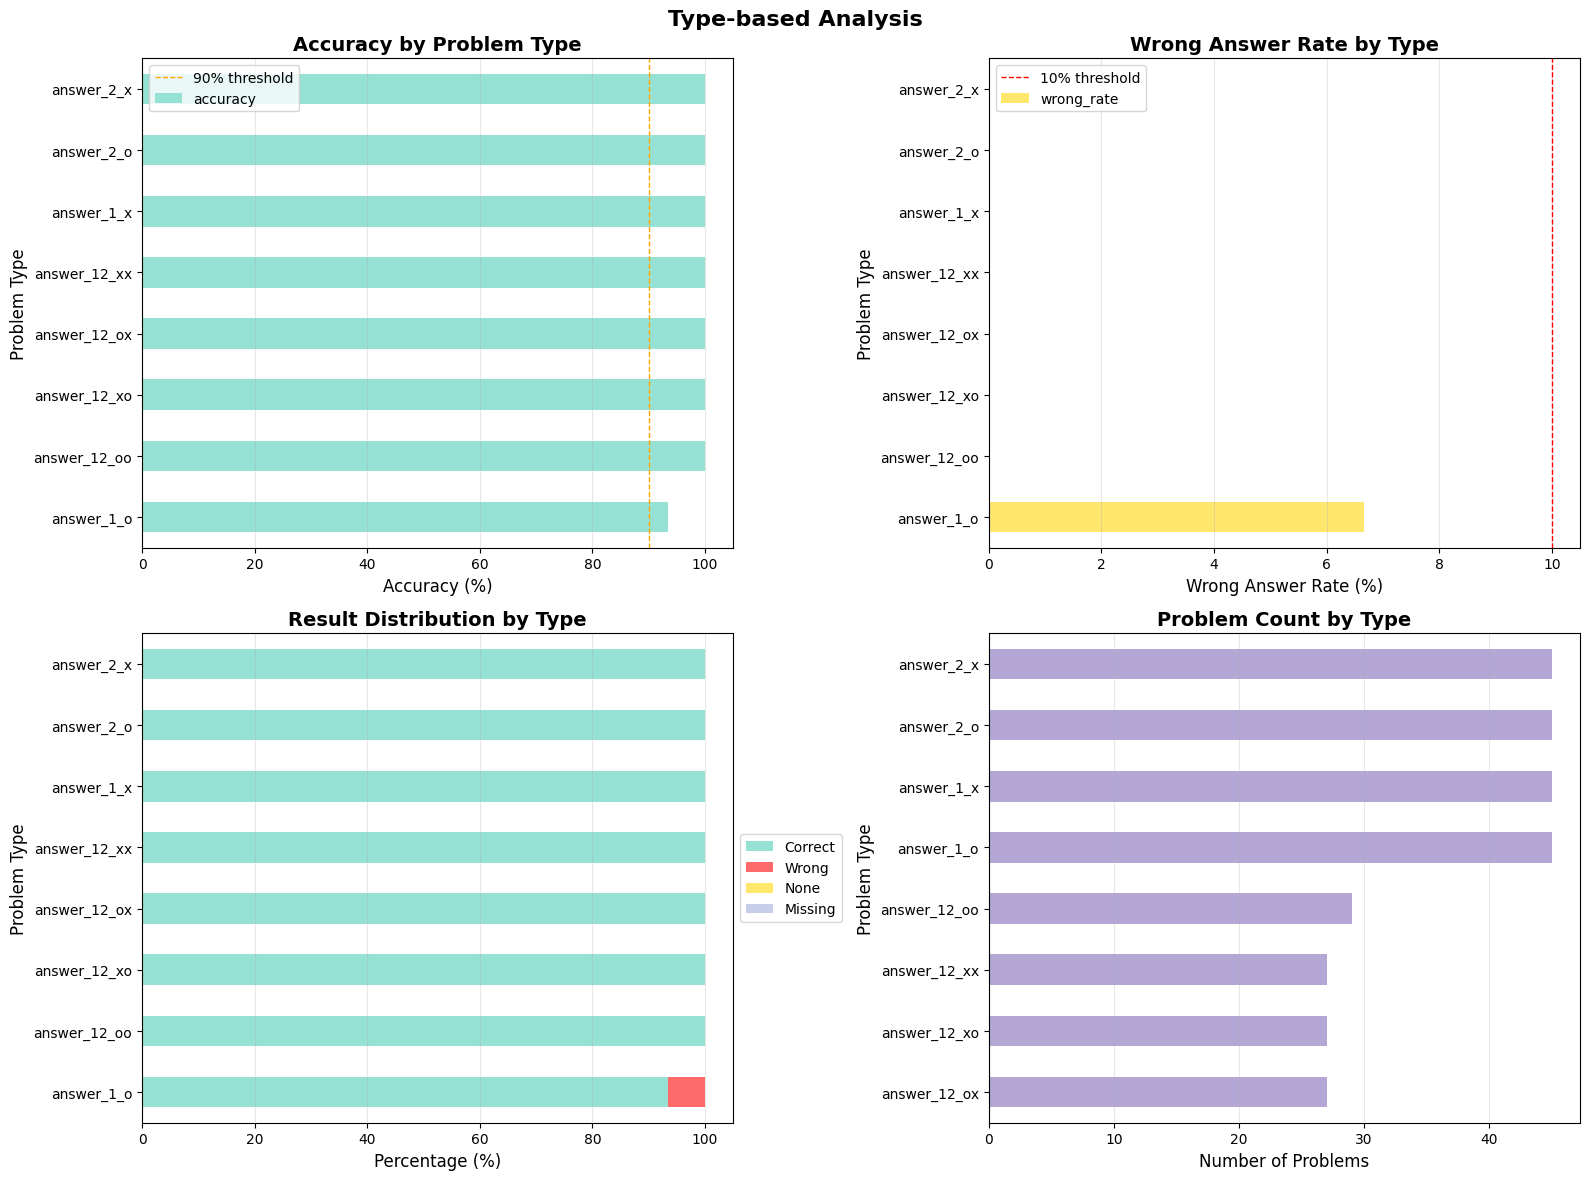

In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

if merged_df['problem_type'].notna().sum() > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Type-based Analysis', fontsize=16, fontweight='bold')
    
    # 1. 유형별 정확도 막대 그래프
    ax1 = axes[0, 0]
    type_stats_sorted = type_stats.sort_values('accuracy', ascending=True)
    colors = ['#FF6B6B' if acc < 80 else '#4ECDC4' if acc < 90 else '#95E1D3' 
              for acc in type_stats_sorted['accuracy']]
    type_stats_sorted['accuracy'].plot(kind='barh', ax=ax1, color=colors)
    ax1.set_xlabel('Accuracy (%)', fontsize=12)
    ax1.set_ylabel('Problem Type', fontsize=12)
    ax1.set_title('Accuracy by Problem Type', fontsize=14, fontweight='bold')
    ax1.axvline(x=90, color='orange', linestyle='--', linewidth=1, label='90% threshold')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # 2. 유형별 오답률 막대 그래프
    ax2 = axes[0, 1]
    type_stats_sorted_wrong = type_stats.sort_values('wrong_rate', ascending=False)
    colors_wrong = ['#FF6B6B' if rate > 10 else '#FFE66D' if rate > 5 else '#95E1D3' 
                    for rate in type_stats_sorted_wrong['wrong_rate']]
    type_stats_sorted_wrong['wrong_rate'].plot(kind='barh', ax=ax2, color=colors_wrong)
    ax2.set_xlabel('Wrong Answer Rate (%)', fontsize=12)
    ax2.set_ylabel('Problem Type', fontsize=12)
    ax2.set_title('Wrong Answer Rate by Type', fontsize=14, fontweight='bold')
    ax2.axvline(x=10, color='red', linestyle='--', linewidth=1, label='10% threshold')
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)
    
    # 3. 유형별 결과 분포 (스택 바 차트)
    ax3 = axes[1, 0]
    type_result_pct = type_stats[['correct', 'wrong', 'none', 'missing']].div(type_stats['total'], axis=0) * 100
    type_result_pct.plot(kind='barh', stacked=True, ax=ax3, 
                         color=['#95E1D3', '#FF6B6B', '#FFE66D', '#C7CEEA'])
    ax3.set_xlabel('Percentage (%)', fontsize=12)
    ax3.set_ylabel('Problem Type', fontsize=12)
    ax3.set_title('Result Distribution by Type', fontsize=14, fontweight='bold')
    ax3.legend(['Correct', 'Wrong', 'None', 'Missing'], loc='center left', bbox_to_anchor=(1, 0.5))
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. 유형별 문제 수
    ax4 = axes[1, 1]
    type_stats['total'].sort_values(ascending=True).plot(kind='barh', ax=ax4, color='#B4A7D6')
    ax4.set_xlabel('Number of Problems', fontsize=12)
    ax4.set_ylabel('Problem Type', fontsize=12)
    ax4.set_title('Problem Count by Type', fontsize=14, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    type_viz_path = output_dir / "type_analysis_visualization.png"
    plt.savefig(type_viz_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 유형별 분석 시각화 저장: {type_viz_path}")
    plt.show()
else:
    print("⚠️ 유형 정보가 없어 시각화를 생성할 수 없습니다.")

## 8. 전체 시각화


💾 시각화 저장: accuracy_visualization.png


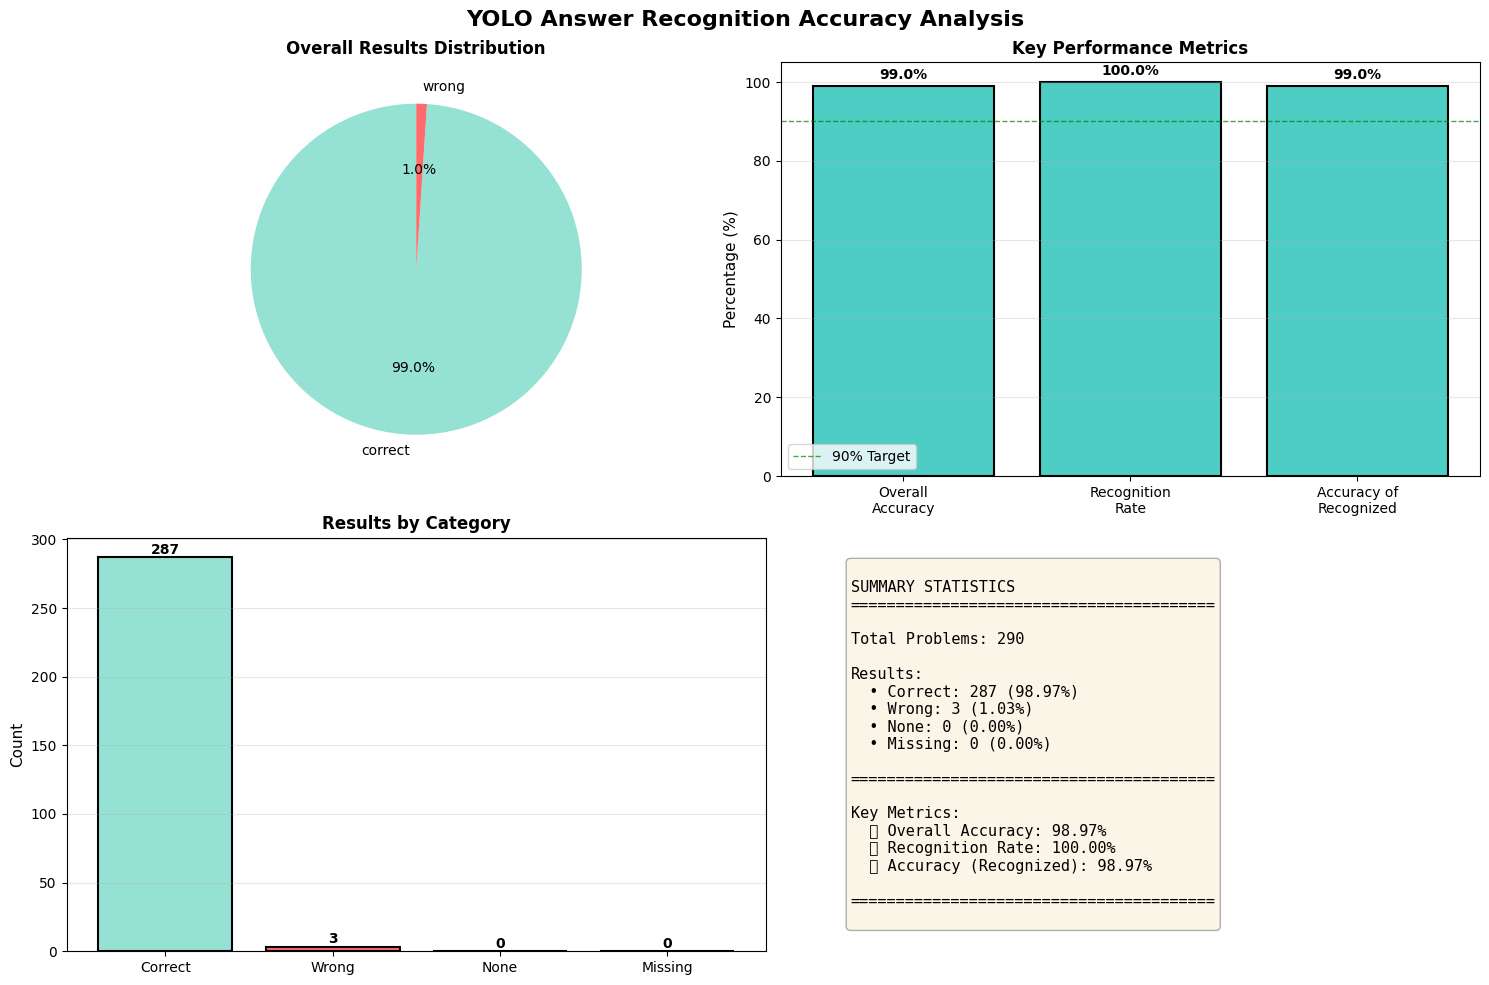

In [9]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (시스템에 따라 조정 필요)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# 시각화 설정
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('YOLO Answer Recognition Accuracy Analysis', fontsize=16, fontweight='bold')

# 1. 전체 결과 파이 차트
result_counts = merged_df['result'].value_counts()
colors = {'correct': '#95E1D3', 'wrong': '#FF6B6B', 'none': '#FFE66D', 'missing': '#C7CEEA'}
result_colors = [colors.get(x, '#CCCCCC') for x in result_counts.index]

axes[0, 0].pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%',
               colors=result_colors, startangle=90)
axes[0, 0].set_title('Overall Results Distribution', fontweight='bold')

# 2. 정확도 지표 막대 그래프
metrics = ['Overall\nAccuracy', 'Recognition\nRate', 'Accuracy of\nRecognized']
values = [accuracy, recognition_rate, accuracy_of_recognized]
bar_colors = ['#4ECDC4' if v >= 90 else '#FFE66D' if v >= 80 else '#FF6B6B' for v in values]

bars = axes[0, 1].bar(metrics, values, color=bar_colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Percentage (%)', fontsize=11)
axes[0, 1].set_title('Key Performance Metrics', fontweight='bold')
axes[0, 1].set_ylim(0, 105)
axes[0, 1].axhline(y=90, color='green', linestyle='--', linewidth=1, alpha=0.7, label='90% Target')
axes[0, 1].legend()

# 막대 위에 값 표시
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

axes[0, 1].grid(axis='y', alpha=0.3)

# 3. 결과 카테고리별 개수
categories = ['Correct', 'Wrong', 'None', 'Missing']
counts = [correct_count, wrong_count, none_count, missing_count]
cat_colors = ['#95E1D3', '#FF6B6B', '#FFE66D', '#C7CEEA']

bars = axes[1, 0].bar(categories, counts, color=cat_colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('Results by Category', fontweight='bold')

# 막대 위에 값 표시
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{count}', ha='center', va='bottom', fontweight='bold')

axes[1, 0].grid(axis='y', alpha=0.3)

# 4. 누적 통계 표
axes[1, 1].axis('off')
stats_text = f"""
SUMMARY STATISTICS
{"="*40}

Total Problems: {total_count}

Results:
  • Correct: {correct_count} ({correct_count/total_count*100:.2f}%)
  • Wrong: {wrong_count} ({wrong_count/total_count*100:.2f}%)
  • None: {none_count} ({none_count/total_count*100:.2f}%)
  • Missing: {missing_count} ({missing_count/total_count*100:.2f}%)

{"="*40}

Key Metrics:
  🎯 Overall Accuracy: {accuracy:.2f}%
  📝 Recognition Rate: {recognition_rate:.2f}%
  ✨ Accuracy (Recognized): {accuracy_of_recognized:.2f}%

{"="*40}
"""

axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()

# 저장
viz_path = output_dir / "accuracy_visualization.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n💾 시각화 저장: {viz_path}")

plt.show()

## 9. 누락 문제 (Missing)

In [10]:
# 누락된 문제 (results에 없음)
missing_df = merged_df[merged_df['result'] == 'missing'].copy()

print("="*60)
print(f"🔍 누락된 문제 분석 (총 {len(missing_df)}개)")
print("="*60)

if len(missing_df) > 0:
    print("\n누락 목록:")
    display(missing_df[['page_number', 'problem_number', 'correct_answer', 'problem_type']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 누락 통계
    print("\n📄 페이지별 누락 통계:")
    page_missing = missing_df.groupby('page_number').size().reset_index(name='missing_count')
    page_missing = page_missing.sort_values('missing_count', ascending=False)
    display(page_missing.head(10))
else:
    print("\n✅ 누락된 문제가 없습니다!")

🔍 누락된 문제 분석 (총 0개)

✅ 누락된 문제가 없습니다!


## 10. None 답안 분석

In [11]:
# None 답안
none_df = merged_df[merged_df['result'] == 'none'].copy()

print("="*60)
print(f"⚠️ None 답안 분석 (총 {len(none_df)}개)")
print("="*60)

if len(none_df) > 0:
    print("\nNone 답안 목록:")
    display(none_df[['page_number', 'problem_number', 'correct_answer', 'problem_type']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 None 통계
    print("\n📄 페이지별 None 답안 통계:")
    page_none = none_df.groupby('page_number').size().reset_index(name='none_count')
    page_none = page_none.sort_values('none_count', ascending=False)
    display(page_none.head(10))
else:
    print("\n✅ None 답안이 없습니다!")

⚠️ None 답안 분석 (총 0개)

✅ None 답안이 없습니다!


## 11. 오답 분석

In [12]:
# 오답
wrong_df = merged_df[merged_df['result'] == 'wrong'].copy()

print("="*60)
print(f"❌ 오답 분석 (총 {len(wrong_df)}개)")
print("="*60)

if len(wrong_df) > 0:
    print("\n오답 목록:")
    display(wrong_df[['page_number', 'problem_number', 'correct_answer', 'predicted_answer', 'problem_type']].sort_values(['page_number', 'problem_number']))
    
    # 페이지별 오답 통계
    print("\n📄 페이지별 오답 통계:")
    page_wrong = wrong_df.groupby('page_number').size().reset_index(name='wrong_count')
    page_wrong = page_wrong.sort_values('wrong_count', ascending=False)
    display(page_wrong.head(10))
else:
    print("\n✅ 오답이 없습니다!")

❌ 오답 분석 (총 3개)

오답 목록:


,page_number,problem_number,correct_answer,predicted_answer,problem_type
113,105,04,4,5,answer_1_o
119,106,10,4,1,answer_1_o
134,112,25,4,2,answer_1_o



📄 페이지별 오답 통계:


,page_number,wrong_count
0,105,1
1,106,1
2,112,1


## 12. 페이지별 정확도

In [13]:
# 페이지별 정확도 계산
page_stats = merged_df.groupby('page_number').agg({
    'result': 'count',
}).rename(columns={'result': 'total'})

page_stats['correct'] = merged_df[merged_df['result'] == 'correct'].groupby('page_number').size()
page_stats['wrong'] = merged_df[merged_df['result'] == 'wrong'].groupby('page_number').size()
page_stats['none'] = merged_df[merged_df['result'] == 'none'].groupby('page_number').size()
page_stats['missing'] = merged_df[merged_df['result'] == 'missing'].groupby('page_number').size()

page_stats = page_stats.fillna(0).astype(int)
page_stats['accuracy'] = (page_stats['correct'] / page_stats['total'] * 100).round(2)
page_stats = page_stats.sort_values('accuracy', ascending=False)

print("="*60)
print("📊 페이지별 정확도")
print("="*60)
display(page_stats)

# 정확도가 낮은 페이지
print("\n⚠️ 정확도가 낮은 페이지 (80% 미만):")
low_accuracy_pages = page_stats[page_stats['accuracy'] < 80]
if len(low_accuracy_pages) > 0:
    display(low_accuracy_pages)
else:
    print("✅ 모든 페이지가 80% 이상의 정확도를 보입니다!")

📊 페이지별 정확도


,total,correct,wrong,none,missing,accuracy
page_number,,,,,,
10,1,1,0,0,0,100.0
100,2,2,0,0,0,100.0
101,2,2,0,0,0,100.0
102,2,2,0,0,0,100.0
103,2,2,0,0,0,100.0
...,...,...,...,...,...,...
95,2,2,0,0,0,100.0
99,2,2,0,0,0,100.0
105,5,4,1,0,0,80.0



⚠️ 정확도가 낮은 페이지 (80% 미만):


,total,correct,wrong,none,missing,accuracy
page_number,,,,,,
112,2,1,1,0,0,50.0


## 13. 결과 저장

In [14]:
# 상세 결과 저장
detailed_results_path = output_dir / "detailed_comparison.csv"
merged_df.to_csv(detailed_results_path, index=False, encoding='utf-8-sig')
print(f"\n💾 상세 비교 결과 저장: {detailed_results_path}")

# 페이지별 통계 저장
page_stats_path = output_dir / "page_statistics.csv"
page_stats.to_csv(page_stats_path, encoding='utf-8-sig')
print(f"💾 페이지별 통계 저장: {page_stats_path}")

# 유형별 통계 저장
if merged_df['problem_type'].notna().sum() > 0:
    type_stats_path = output_dir / "type_statistics.csv"
    type_stats.to_csv(type_stats_path, encoding='utf-8-sig')
    print(f"💾 유형별 통계 저장: {type_stats_path}")

# 요약 리포트 저장
summary_path = output_dir / "accuracy_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("YOLO 답안 인식 정확도 분석 보고서\n")
    f.write("(페이지번호 + 문제번호 기준)\n")
    f.write("="*60 + "\n\n")
    
    f.write("📊 전체 통계\n")
    f.write("-"*60 + "\n")
    f.write(f"총 문제 수: {total_count}개\n")
    f.write(f"정답: {correct_count}개 ({correct_count/total_count*100:.2f}%)\n")
    f.write(f"오답: {wrong_count}개 ({wrong_count/total_count*100:.2f}%)\n")
    f.write(f"None: {none_count}개 ({none_count/total_count*100:.2f}%)\n")
    f.write(f"누락: {missing_count}개 ({missing_count/total_count*100:.2f}%)\n\n")
    
    f.write("="*60 + "\n")
    f.write(f"🎯 전체 정확도: {accuracy:.2f}%\n")
    f.write(f"📝 인식 성공률 (누락 제외): {recognition_rate:.2f}%\n")
    f.write(f"✨ 인식된 것 중 정확도: {accuracy_of_recognized:.2f}%\n")
    f.write("="*60 + "\n\n")
    
    # 유형별 통계 추가
    if merged_df['problem_type'].notna().sum() > 0:
        f.write("\n📊 유형별 통계\n")
        f.write("-"*60 + "\n")
        for problem_type in type_stats.index:
            stats = type_stats.loc[problem_type]
            f.write(f"\n유형: {problem_type}\n")
            f.write(f"  총 문제: {stats['total']}개\n")
            f.write(f"  정답: {stats['correct']}개 ({stats['accuracy']:.2f}%)\n")
            f.write(f"  오답: {stats['wrong']}개 ({stats['wrong_rate']:.2f}%)\n")
            f.write(f"  None: {stats['none']}개 ({stats['none_rate']:.2f}%)\n")
            f.write(f"  누락: {stats['missing']}개 ({stats['missing_rate']:.2f}%)\n")
    
    if len(missing_df) > 0:
        f.write(f"\n🔍 누락된 문제: {len(missing_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in missing_df.iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 정답 {row['correct_answer']}\n")
    
    if len(none_df) > 0:
        f.write(f"\n⚠️ None 답안: {len(none_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in none_df.head(20).iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 정답 {row['correct_answer']}\n")
        if len(none_df) > 20:
            f.write(f"... 외 {len(none_df)-20}개\n")
    
    if len(wrong_df) > 0:
        f.write(f"\n❌ 오답: {len(wrong_df)}개\n")
        f.write("-"*60 + "\n")
        for _, row in wrong_df.head(20).iterrows():
            f.write(f"페이지 {row['page_number']}, 문제 {row['problem_number']}, 유형 {row['problem_type']}, 정답 {row['correct_answer']}, 예측 {row['predicted_answer']}\n")
        if len(wrong_df) > 20:
            f.write(f"... 외 {len(wrong_df)-20}개\n")

print(f"💾 요약 리포트 저장: {summary_path}")

print("\n" + "="*60)
print("✅ 모든 분석이 완료되었습니다!")
print("="*60)


💾 상세 비교 결과 저장: detailed_comparison.csv
💾 페이지별 통계 저장: page_statistics.csv
💾 유형별 통계 저장: type_statistics.csv
💾 요약 리포트 저장: accuracy_summary.txt

✅ 모든 분석이 완료되었습니다!


## 14. 최종 요약

In [15]:
from IPython.display import Markdown, display

summary_md = f"""
# 📊 최종 분석 요약

## 🎯 전체 정확도: **{accuracy:.2f}%**

---

### 📈 주요 지표
- **매칭 기준**: 페이지번호 + 문제번호
- **인식 성공률**: {recognition_rate:.2f}% (누락 제외)
- **인식된 것 중 정확도**: {accuracy_of_recognized:.2f}%

---

### 📊 상세 통계
| 구분 | 개수 | 비율 |
|------|------|------|
| ✅ 정답 | {correct_count}개 | {correct_count/total_count*100:.2f}% |
| ❌ 오답 | {wrong_count}개 | {wrong_count/total_count*100:.2f}% |
| ⚠️ None | {none_count}개 | {none_count/total_count*100:.2f}% |
| 🔍 누락 | {missing_count}개 | {missing_count/total_count*100:.2f}% |
| **📘 전체** | **{total_count}개** | **100.00%** |
"""

# 유형별 요약 추가
if merged_df['problem_type'].notna().sum() > 0:
    summary_md += "\n---\n\n### 📊 유형별 정확도\n\n"
    summary_md += "| 유형 | 문제 수 | 정확도 | 오답률 |\n"
    summary_md += "|------|---------|--------|--------|\n"
    for problem_type in type_stats.sort_values('accuracy', ascending=False).index:
        stats = type_stats.loc[problem_type]
        summary_md += f"| {problem_type} | {stats['total']}개 | {stats['accuracy']:.2f}% | {stats['wrong_rate']:.2f}% |\n"

summary_md += """

---

### 💡 개선 포인트
""" 

if missing_count > 0:
    summary_md += f"\n- 🔍 **누락 문제 해결**: {missing_count}개 문제가 results에 없습니다. Section 검출 문제일 수 있습니다."

if none_count > 0:
    summary_md += f"\n- ⚠️ **None 답안 개선**: {none_count}개 문제의 답안이 인식되지 않았습니다."

if wrong_count > 0:
    summary_md += f"\n- ❌ **오답 분석**: {wrong_count}개 문제의 답안이 잘못 인식되었습니다."
    if merged_df['problem_type'].notna().sum() > 0:
        high_wrong_types = type_stats[type_stats['wrong_rate'] > 10]
        if len(high_wrong_types) > 0:
            summary_md += f"\n  - 특히 다음 유형의 오답률이 높습니다: {', '.join(high_wrong_types.index.astype(str))}"

if accuracy >= 95:
    summary_md += "\n\n### 🎉 우수한 성능!"
    summary_md += "\n95% 이상의 정확도를 달성했습니다!"
elif accuracy >= 90:
    summary_md += "\n\n### 👍 양호한 성능"
    summary_md += "\n90% 이상의 정확도입니다. 조금 더 개선하면 더 좋습니다!"
else:
    summary_md += "\n\n### 🔧 개선 필요"
    summary_md += "\n정확도가 90% 미만입니다. 위의 개선 포인트를 참고하여 모델을 개선하세요."

summary_md += f"""

---

### 📁 생성된 파일
- `detailed_comparison.csv`: 전체 비교 결과
- `page_statistics.csv`: 파일별 통계
- `type_statistics.csv`: 유형별 통계 ⭐ NEW
- `accuracy_summary.txt`: 요약 리포트
- `accuracy_visualization.png`: 전체 시각화 차트
- `type_analysis_visualization.png`: 유형별 분석 시각화 ⭐ NEW
"""

display(Markdown(summary_md))


# 📊 최종 분석 요약

## 🎯 전체 정확도: **98.97%**

---

### 📈 주요 지표
- **매칭 기준**: 페이지번호 + 문제번호
- **인식 성공률**: 100.00% (누락 제외)
- **인식된 것 중 정확도**: 98.97%

---

### 📊 상세 통계
| 구분 | 개수 | 비율 |
|------|------|------|
| ✅ 정답 | 287개 | 98.97% |
| ❌ 오답 | 3개 | 1.03% |
| ⚠️ None | 0개 | 0.00% |
| 🔍 누락 | 0개 | 0.00% |
| **📘 전체** | **290개** | **100.00%** |

---

### 📊 유형별 정확도

| 유형 | 문제 수 | 정확도 | 오답률 |
|------|---------|--------|--------|
| answer_12_oo | 29.0개 | 100.00% | 0.00% |
| answer_12_xo | 27.0개 | 100.00% | 0.00% |
| answer_12_ox | 27.0개 | 100.00% | 0.00% |
| answer_12_xx | 27.0개 | 100.00% | 0.00% |
| answer_2_o | 45.0개 | 100.00% | 0.00% |
| answer_1_x | 45.0개 | 100.00% | 0.00% |
| answer_2_x | 45.0개 | 100.00% | 0.00% |
| answer_1_o | 45.0개 | 93.33% | 6.67% |


---

### 💡 개선 포인트

- ❌ **오답 분석**: 3개 문제의 답안이 잘못 인식되었습니다.

### 🎉 우수한 성능!
95% 이상의 정확도를 달성했습니다!

---

### 📁 생성된 파일
- `detailed_comparison.csv`: 전체 비교 결과
- `page_statistics.csv`: 파일별 통계
- `type_statistics.csv`: 유형별 통계 ⭐ NEW
- `accuracy_summary.txt`: 요약 리포트
- `accuracy_visualization.png`: 전체 시각화 차트
- `type_analysis_visualization.png`: 유형별 분석 시각화 ⭐ NEW
